# DDRM Setup

In [ ]:
import os
from pathlib import Path
import torch

# paths
PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")
DATA_DIR = PROJECT_ROOT / "data" / "img_align_celeba"

# cache
os.environ["HF_HOME"] = f"/scratch/{os.environ['USER']}/huggingface"
os.environ["TRANSFORMERS_CACHE"] = os.environ["HF_HOME"]
os.environ["HUGGINGFACE_HUB_CACHE"] = os.environ["HF_HOME"]

# device
device = "cuda" if torch.cuda.is_available() else "cpu"

print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("DATA_DIR exists:", DATA_DIR.exists())
print("HF_HOME:", os.environ["HF_HOME"])
print("device:", device)

PROJECT_ROOT exists: True
DATA_DIR exists: True
HF_HOME: /scratch/hbbeth/huggingface
device: cuda


In [ ]:
import os

# Uncomment this line and add the path where the project lives
# %cd /path/Sample-Adaptive-Diffusion-Steps

if not os.path.exists("external/ddrm"):
    !mkdir -p external
    !git clone https://github.com/bahjat-kawar/ddrm.git external/ddrm
else:
    print("DDRM repo already exists")

/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps


/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Cloning into 'external/ddrm'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 83 (delta 28), reused 21 (delta 21), pack-reused 38 (from 1)
Receiving objects: 100% (83/83), 3.20 MiB | 30.33 MiB/s, done.
Resolving deltas: 100% (29/29), done.


In [3]:
from pathlib import Path

ddrm_root = PROJECT_ROOT / "external" / "ddrm"
print("DDRM exists:", ddrm_root.exists())
print(ddrm_root)

DDRM exists: True
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/external/ddrm


In [6]:
import torch
import numpy
import scipy
import yaml
import cv2
from tqdm import tqdm

print("core imports ok")

core imports ok


## Setting LPIPS threshold (using OOD images)

In [ ]:
import os
from pathlib import Path
from PIL import Image
import torch
import torchvision.transforms as T
import lpips

PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")
DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
device = "cuda" if torch.cuda.is_available() else "cpu"

lpips_model = lpips.LPIPS(net="alex").to(device)
to_tensor = T.ToTensor()

def load_img(path):
    img = Image.open(path).convert("RGB")
    return to_tensor(img).unsqueeze(0).to(device)

def to_lpips_range(x):
    return x * 2 - 1

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


In [ ]:
run_dirs = {
    5:  DDR_ROOT / "exp" / "image_samples" / "run_k5_100imgs",
    10: DDR_ROOT / "exp" / "image_samples" / "run_k10_100imgs",
    20: DDR_ROOT / "exp" / "image_samples" / "run_k20_100imgs",
    30: DDR_ROOT / "exp" / "image_samples" / "run_k30_100imgs",
    50: DDR_ROOT / "exp" / "image_samples" / "run_k50_100imgs",
    100: DDR_ROOT / "exp" / "image_samples" / "run_k100_100imgs",
}

In [3]:
results = []

num_images = 100

for k, folder in run_dirs.items():
    for idx in range(num_images):
        orig_path = folder / f"orig_{idx}.png"
        restored_path = folder / f"{idx}_-1.png"

        x0 = load_img(orig_path)
        xr = load_img(restored_path)

        with torch.no_grad():
            score = lpips_model(
                to_lpips_range(xr),
                to_lpips_range(x0)
            ).item()

        results.append((idx, k, score))
        print(f"image={idx}, steps={k}, LPIPS={score:.5f}")

image=0, steps=5, LPIPS=0.29796
image=1, steps=5, LPIPS=0.36053
image=2, steps=5, LPIPS=0.42021
image=3, steps=5, LPIPS=0.31491
image=4, steps=5, LPIPS=0.45539
image=5, steps=5, LPIPS=0.30265
image=6, steps=5, LPIPS=0.16433
image=7, steps=5, LPIPS=0.34751
image=8, steps=5, LPIPS=0.32444
image=9, steps=5, LPIPS=0.16566
image=10, steps=5, LPIPS=0.51275
image=11, steps=5, LPIPS=0.37612
image=12, steps=5, LPIPS=0.43496
image=13, steps=5, LPIPS=0.32941
image=14, steps=5, LPIPS=0.29885
image=15, steps=5, LPIPS=0.25651
image=16, steps=5, LPIPS=0.32564
image=17, steps=5, LPIPS=0.14929
image=18, steps=5, LPIPS=0.20713
image=19, steps=5, LPIPS=0.31696
image=20, steps=5, LPIPS=0.38465
image=21, steps=5, LPIPS=0.30673
image=22, steps=5, LPIPS=0.29789
image=23, steps=5, LPIPS=0.24330
image=24, steps=5, LPIPS=0.20310
image=25, steps=5, LPIPS=0.65140
image=26, steps=5, LPIPS=0.33573
image=27, steps=5, LPIPS=0.38953
image=28, steps=5, LPIPS=0.46819
image=29, steps=5, LPIPS=0.39068
image=30, steps=5, L

In [4]:
from collections import defaultdict

best_per_image = defaultdict(lambda: (None, float("inf")))

for idx, k, score in results:
    if score < best_per_image[idx][1]:
        best_per_image[idx] = (k, score)

print("\nBest step count per image:")
for idx in sorted(best_per_image):
    k, score = best_per_image[idx]
    print(f"image={idx}: best_k={k}, best_LPIPS={score:.5f}")


Best step count per image:
image=0: best_k=100, best_LPIPS=0.17467
image=1: best_k=100, best_LPIPS=0.22342
image=2: best_k=100, best_LPIPS=0.33383
image=3: best_k=100, best_LPIPS=0.17094
image=4: best_k=100, best_LPIPS=0.33434
image=5: best_k=30, best_LPIPS=0.19792
image=6: best_k=100, best_LPIPS=0.04077
image=7: best_k=100, best_LPIPS=0.17085
image=8: best_k=100, best_LPIPS=0.21532
image=9: best_k=100, best_LPIPS=0.10792
image=10: best_k=50, best_LPIPS=0.38524
image=11: best_k=100, best_LPIPS=0.24021
image=12: best_k=100, best_LPIPS=0.35404
image=13: best_k=100, best_LPIPS=0.24585
image=14: best_k=50, best_LPIPS=0.18249
image=15: best_k=100, best_LPIPS=0.09339
image=16: best_k=100, best_LPIPS=0.17445
image=17: best_k=100, best_LPIPS=0.08097
image=18: best_k=50, best_LPIPS=0.12369
image=19: best_k=100, best_LPIPS=0.23810
image=20: best_k=100, best_LPIPS=0.17619
image=21: best_k=100, best_LPIPS=0.18624
image=22: best_k=100, best_LPIPS=0.23492
image=23: best_k=100, best_LPIPS=0.19915
im

In [5]:
# Freeze reference LPIPS per image from your CURRENT results
# (do this once, do NOT recompute after adding new runs)

from collections import defaultdict

# build per-image lookup
lpips_lookup = defaultdict(dict)
for idx, k, score in results:
    lpips_lookup[idx][k] = score

# choose reference step per image = step with lowest LPIPS in CURRENT results
reference_step_per_image = {}
reference_lpips_per_image = {}

for idx, step_dict in lpips_lookup.items():
    best_k = min(step_dict, key=lambda k: step_dict[k])
    reference_step_per_image[idx] = best_k
    reference_lpips_per_image[idx] = step_dict[best_k]

print("Frozen references:")
for idx in sorted(reference_step_per_image):
    print(f"image={idx}, ref_step={reference_step_per_image[idx]}, ref_LPIPS={reference_lpips_per_image[idx]:.5f}")

Frozen references:
image=0, ref_step=100, ref_LPIPS=0.17467
image=1, ref_step=100, ref_LPIPS=0.22342
image=2, ref_step=100, ref_LPIPS=0.33383
image=3, ref_step=100, ref_LPIPS=0.17094
image=4, ref_step=100, ref_LPIPS=0.33434
image=5, ref_step=30, ref_LPIPS=0.19792
image=6, ref_step=100, ref_LPIPS=0.04077
image=7, ref_step=100, ref_LPIPS=0.17085
image=8, ref_step=100, ref_LPIPS=0.21532
image=9, ref_step=100, ref_LPIPS=0.10792
image=10, ref_step=50, ref_LPIPS=0.38524
image=11, ref_step=100, ref_LPIPS=0.24021
image=12, ref_step=100, ref_LPIPS=0.35404
image=13, ref_step=100, ref_LPIPS=0.24585
image=14, ref_step=50, ref_LPIPS=0.18249
image=15, ref_step=100, ref_LPIPS=0.09339
image=16, ref_step=100, ref_LPIPS=0.17445
image=17, ref_step=100, ref_LPIPS=0.08097
image=18, ref_step=50, ref_LPIPS=0.12369
image=19, ref_step=100, ref_LPIPS=0.23810
image=20, ref_step=100, ref_LPIPS=0.17619
image=21, ref_step=100, ref_LPIPS=0.18624
image=22, ref_step=100, ref_LPIPS=0.23492
image=23, ref_step=100, ref_L

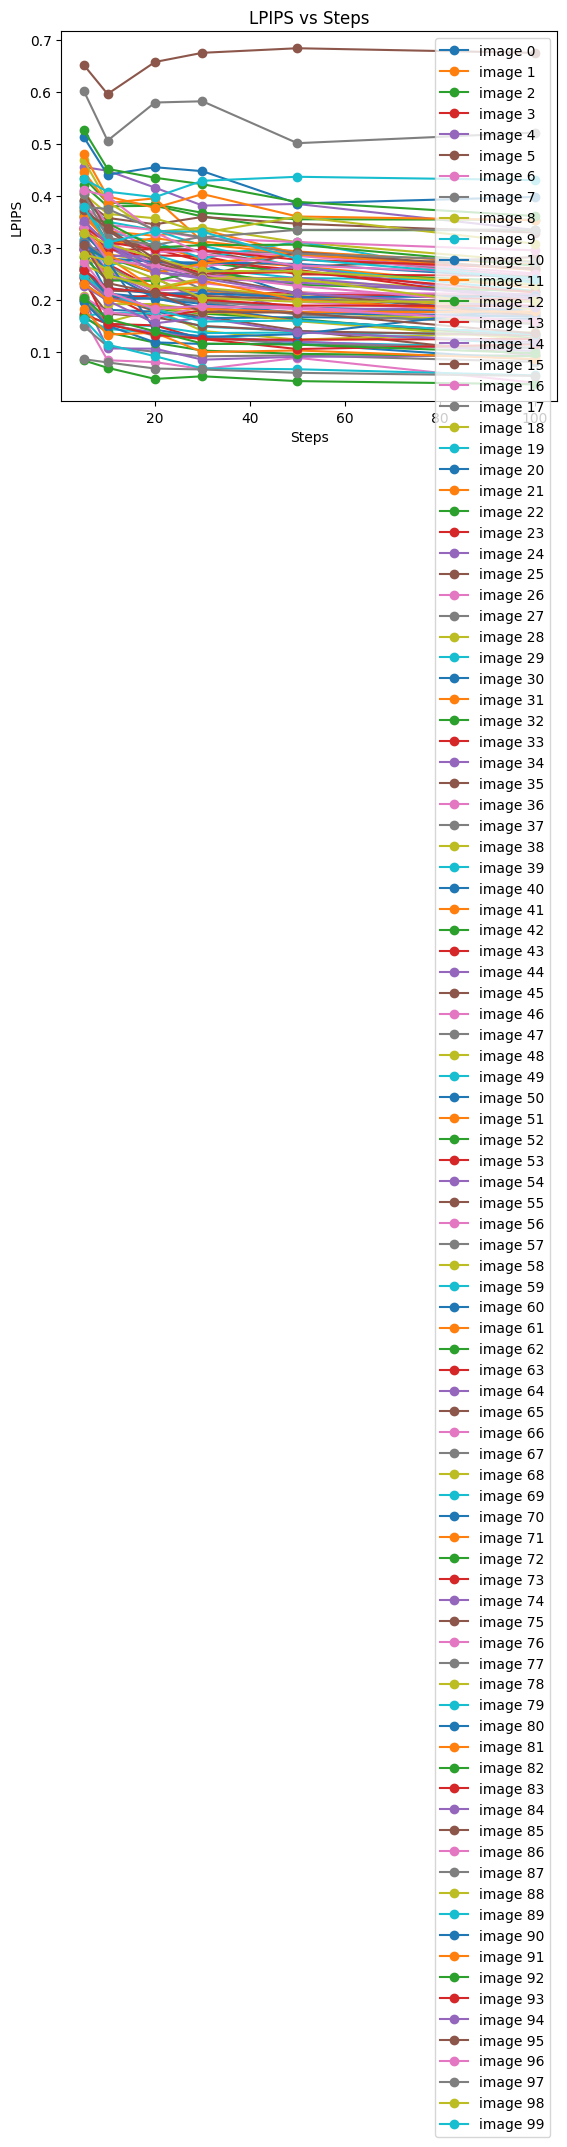

In [6]:
import matplotlib.pyplot as plt

for idx in range(num_images):
    ks = []
    scores = []
    
    for (i, k, s) in results:
        if i == idx:
            ks.append(k)
            scores.append(s)
    
    ks, scores = zip(*sorted(zip(ks, scores)))
    
    plt.plot(ks, scores, marker='o', label=f"image {idx}")

plt.xlabel("Steps")
plt.ylabel("LPIPS")
plt.title("LPIPS vs Steps")
plt.legend()
plt.show()

In [7]:
from collections import defaultdict

# ---- NEW: freeze reference once ----
def get_reference_lpips_per_image(results):
    """
    Freeze reference LPIPS per image based on CURRENT results.
    Should be run ONLY ONCE after coarse sweep.
    """
    ref_lpips = {}
    ref_step = {}

    for idx, k, lp in results:
        if idx not in ref_lpips or lp < ref_lpips[idx]:
            ref_lpips[idx] = lp
            ref_step[idx] = k

    return ref_lpips, ref_step


def coarse_kstar_relative(results, reference_lpips, epsilon=0.1):
    """
    Returns smallest k such that LPIPS(k) <= (1+epsilon)*reference
    """
    by_image = defaultdict(list)
    for idx, k, lp in results:
        by_image[idx].append((k, lp))

    kstar_dict = {}
    for idx, vals in by_image.items():
        vals = sorted(vals, key=lambda x: x[0])
        threshold = (1 + epsilon) * reference_lpips[idx]

        chosen_k = None
        for k, lp in vals:
            if lp <= threshold:
                chosen_k = k
                break

        kstar_dict[idx] = chosen_k

    return kstar_dict


def find_refinement_intervals(results, reference_lpips, epsilon=0.1):
    """
    Uses FIXED reference instead of dynamic best LPIPS
    """
    by_image = defaultdict(list)
    for idx, k, lp in results:
        by_image[idx].append((k, lp))

    intervals = {}

    for idx, vals in by_image.items():
        vals = sorted(vals, key=lambda x: x[0])
        threshold = (1 + epsilon) * reference_lpips[idx]

        first_k, first_lp = vals[0]
        if first_lp <= threshold:
            intervals[idx] = (None, first_k)
            continue

        low_k, high_k = None, None
        prev_k, prev_lp = vals[0]

        for k, lp in vals[1:]:
            if prev_lp > threshold and lp <= threshold:
                low_k = prev_k
                high_k = k
                break
            prev_k, prev_lp = k, lp

        if high_k is None:
            intervals[idx] = (vals[-1][0], None)
        else:
            intervals[idx] = (low_k, high_k)

    return intervals

### ----------------------- DO NOT TOUCH AGAIN, ONLY ONCE -----------------------

In [8]:
reference_lpips, reference_steps = get_reference_lpips_per_image(results)

print("Frozen reference:")
for i in sorted(reference_steps):
    print(f"image={i}, ref_step={reference_steps[i]}, ref_lpips={reference_lpips[i]:.5f}")

Frozen reference:
image=0, ref_step=100, ref_lpips=0.17467
image=1, ref_step=100, ref_lpips=0.22342
image=2, ref_step=100, ref_lpips=0.33383
image=3, ref_step=100, ref_lpips=0.17094
image=4, ref_step=100, ref_lpips=0.33434
image=5, ref_step=30, ref_lpips=0.19792
image=6, ref_step=100, ref_lpips=0.04077
image=7, ref_step=100, ref_lpips=0.17085
image=8, ref_step=100, ref_lpips=0.21532
image=9, ref_step=100, ref_lpips=0.10792
image=10, ref_step=50, ref_lpips=0.38524
image=11, ref_step=100, ref_lpips=0.24021
image=12, ref_step=100, ref_lpips=0.35404
image=13, ref_step=100, ref_lpips=0.24585
image=14, ref_step=50, ref_lpips=0.18249
image=15, ref_step=100, ref_lpips=0.09339
image=16, ref_step=100, ref_lpips=0.17445
image=17, ref_step=100, ref_lpips=0.08097
image=18, ref_step=50, ref_lpips=0.12369
image=19, ref_step=100, ref_lpips=0.23810
image=20, ref_step=100, ref_lpips=0.17619
image=21, ref_step=100, ref_lpips=0.18624
image=22, ref_step=100, ref_lpips=0.23492
image=23, ref_step=100, ref_lp

### ----------------------- END -----------------------

In [ ]:
epsilon = 0.05

kstar_coarse = coarse_kstar_relative(results, reference_lpips, epsilon)
intervals = find_refinement_intervals(results, reference_lpips, epsilon)

print(f"Using epsilon = {epsilon}\n")


for idx in sorted(kstar):
    print(f"image={idx}, k*={kstar[idx]}, interval={intervals[idx]}")

Using epsilon = 0.05

image=0, k*=50, interval=(30, 50)
image=1, k*=50, interval=(30, 50)
image=2, k*=50, interval=(30, 50)
image=3, k*=50, interval=(30, 50)
image=4, k*=50, interval=(30, 50)
image=5, k*=50, interval=(30, 50)


In [9]:
epsilon = 0.1

kstar = coarse_kstar_relative(results, reference_lpips, epsilon)
intervals = find_refinement_intervals(results, reference_lpips, epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar):
    print(f"image={idx}, k*={kstar[idx]}, interval={intervals[idx]}")

Using epsilon = 0.1

image=0, k*=50, interval=(30, 50)
image=1, k*=100, interval=(50, 100)
image=2, k*=30, interval=(20, 30)
image=3, k*=100, interval=(50, 100)
image=4, k*=100, interval=(50, 100)
image=5, k*=30, interval=(20, 30)
image=6, k*=100, interval=(50, 100)
image=7, k*=50, interval=(30, 50)
image=8, k*=100, interval=(50, 100)
image=9, k*=100, interval=(50, 100)
image=10, k*=50, interval=(30, 50)
image=11, k*=100, interval=(50, 100)
image=12, k*=10, interval=(5, 10)
image=13, k*=50, interval=(30, 50)
image=14, k*=50, interval=(30, 50)
image=15, k*=100, interval=(50, 100)
image=16, k*=100, interval=(50, 100)
image=17, k*=100, interval=(50, 100)
image=18, k*=50, interval=(30, 50)
image=19, k*=30, interval=(20, 30)
image=20, k*=100, interval=(50, 100)
image=21, k*=50, interval=(30, 50)
image=22, k*=20, interval=(10, 20)
image=23, k*=10, interval=(5, 10)
image=24, k*=30, interval=(20, 30)
image=25, k*=5, interval=(None, 5)
image=26, k*=100, interval=(50, 100)
image=27, k*=100, inte

In [10]:
import pandas as pd

# convert dict → dataframe
rows = []

for idx, k in kstar.items():
    rows.append({
        "image_idx": idx,
        "kstar": k
    })

df_kstar = pd.DataFrame(rows).sort_values("image_idx").reset_index(drop=True)

df_kstar

,image_idx,kstar
0,0,50
1,1,100
2,2,30
3,3,100
4,4,100
...,...,...
95,95,100
96,96,100
97,97,20
98,98,30


In [ ]:
epsilon = 0.2

kstar_coarse, best_lpips = coarse_kstar_relative(results, epsilon=epsilon)
intervals = find_refinement_intervals(results, epsilon=epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar_coarse):
    print(
        f"image={idx}, "
        f"best_LPIPS={best_lpips[idx]:.5f}, "
        f"coarse_k*={kstar_coarse[idx]}, "
        f"refinement_interval={intervals[idx]}"
    )

In [ ]:
epsilon = 0.3

kstar_coarse, best_lpips = coarse_kstar_relative(results, epsilon=epsilon)
intervals = find_refinement_intervals(results, epsilon=epsilon)

print(f"Using epsilon = {epsilon}\n")

for idx in sorted(kstar_coarse):
    print(
        f"image={idx}, "
        f"best_LPIPS={best_lpips[idx]:.5f}, "
        f"coarse_k*={kstar_coarse[idx]}, "
        f"refinement_interval={intervals[idx]}"
    )

Using epsilon = 0.3

image=0, best_LPIPS=0.00091, coarse_k*=100, refinement_interval=(50, 100)
image=1, best_LPIPS=0.00031, coarse_k*=200, refinement_interval=(100, 200)
image=2, best_LPIPS=0.00834, coarse_k*=30, refinement_interval=(20, 30)
image=3, best_LPIPS=0.00081, coarse_k*=200, refinement_interval=(100, 200)
image=4, best_LPIPS=0.00093, coarse_k*=30, refinement_interval=(20, 30)
image=5, best_LPIPS=0.00087, coarse_k*=100, refinement_interval=(50, 100)


In [11]:
print(sorted(kstar.items()))

[(0, 50), (1, 100), (2, 30), (3, 100), (4, 100), (5, 30), (6, 100), (7, 50), (8, 100), (9, 100), (10, 50), (11, 100), (12, 10), (13, 50), (14, 50), (15, 100), (16, 100), (17, 100), (18, 50), (19, 30), (20, 100), (21, 50), (22, 20), (23, 10), (24, 30), (25, 5), (26, 100), (27, 100), (28, 100), (29, 100), (30, 20), (31, 20), (32, 100), (33, 100), (34, 100), (35, 50), (36, 30), (37, 10), (38, 100), (39, 100), (40, 100), (41, 50), (42, 50), (43, 100), (44, 100), (45, 20), (46, 100), (47, 50), (48, 100), (49, 100), (50, 100), (51, 100), (52, 10), (53, 100), (54, 100), (55, 10), (56, 30), (57, 50), (58, 100), (59, 30), (60, 10), (61, 20), (62, 100), (63, 30), (64, 30), (65, 50), (66, 20), (67, 100), (68, 30), (69, 5), (70, 30), (71, 100), (72, 50), (73, 50), (74, 100), (75, 30), (76, 100), (77, 50), (78, 100), (79, 100), (80, 100), (81, 100), (82, 100), (83, 50), (84, 100), (85, 100), (86, 50), (87, 100), (88, 100), (89, 100), (90, 50), (91, 20), (92, 100), (93, 30), (94, 100), (95, 100), (9

In [28]:
def binary_search_kstar(pass_fn, low_k, high_k):
    """
    Finds the smallest k in [low_k+1, high_k] that passes.
    Assumes:
      - low_k fails
      - high_k passes
    """
    lo = low_k + 1
    hi = high_k

    while lo < hi:
        mid = (lo + hi) // 2
        if pass_fn(mid):
            hi = mid
        else:
            lo = mid + 1

    return lo


def make_pass_fn(lpips_by_step, best_lpips, epsilon):
    """
    lpips_by_step: dict {step: lpips}
    Returns a function pass_fn(k) that checks whether
    LPIPS at step k is within (1 + epsilon) of the best LPIPS.
    """
    threshold = (1 + epsilon) * best_lpips

    def pass_fn(k):
        if k not in lpips_by_step:
            raise ValueError(f"Missing LPIPS for step {k}")
        return lpips_by_step[k] <= threshold

    return pass_fn


def get_dense_steps_from_interval(low_k, high_k):
    """
    Returns all integer steps in the refinement interval.
    Example: (30, 50) -> [31, 32, ..., 50]
    """
    if low_k is None or high_k is None:
        return []
    return list(range(low_k + 1, high_k + 1))

In [19]:
epsilon = 0.1
print(f"Refinement plan for epsilon = {epsilon}\n")

for idx in sorted(intervals):
    low_k, high_k = intervals[idx]
    
    if low_k is None:
        print(f"image={idx}: already passes at the smallest tested step")
    elif high_k is None:
        print(f"image={idx}: did not pass within tested range; test larger steps")
    else:
        dense_steps = get_dense_steps_from_interval(low_k, high_k)
        print(f"image={idx}: refine in [{low_k}, {high_k}] -> test {dense_steps}")

Refinement plan for epsilon = 0.1

image=0: refine in [142, 143] -> test [143]
image=1: refine in [142, 143] -> test [143]
image=2: refine in [49, 50] -> test [50]
image=3: refine in [166, 167] -> test [167]
image=4: refine in [35, 36] -> test [36]
image=5: refine in [166, 167] -> test [167]


In [20]:
from collections import defaultdict

# build per-image LPIPS lookup
lpips_lookup = defaultdict(dict)

for idx, k, score in results:
    lpips_lookup[idx][k] = score

In [21]:
def make_pass_fn_for_image(idx, epsilon):
    best_lp = best_lpips[idx]
    threshold = (1 + epsilon) * best_lp

    def pass_fn(k):
        if k not in lpips_lookup[idx]:
            raise ValueError(f"LPIPS not computed yet for image {idx}, step {k}")
        return lpips_lookup[idx][k] <= threshold

    return pass_fn

In [ ]:
def next_binary_step(idx, low_k, high_k):
    return (low_k + high_k) // 2

In [23]:
epsilon = 0.1
print(f"Binary search suggestions (epsilon={epsilon}):\n")

for idx in sorted(intervals):
    low_k, high_k = intervals[idx]

    if low_k is None or high_k is None:
        print(f"image={idx}: no refinement needed")
        continue

    mid = next_binary_step(idx, low_k, high_k)

    print(f"image={idx}: try step {mid} (between {low_k} and {high_k})")

Binary search suggestions (epsilon=0.1):

image=0: try step 142 (between 142 and 143)
image=1: try step 142 (between 142 and 143)
image=2: try step 49 (between 49 and 50)
image=3: try step 166 (between 166 and 167)
image=4: try step 35 (between 35 and 36)
image=5: try step 166 (between 166 and 167)


### Below are all the suggested steps to run based on the algorithm

In [9]:
run_dirs[40] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k40_refine"
run_dirs[150] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k150_refine"

In [10]:
run_dirs[125] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k125_refine"
run_dirs[45]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k45_refine"
run_dirs[175] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k175_refine"

In [11]:
run_dirs[137] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k137_refine"
run_dirs[47]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k47_refine"
run_dirs[162] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k162_refine"
run_dirs[35]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k35_refine"

In [12]:
run_dirs[143] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k143_refine"
run_dirs[48]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k48_refine"
run_dirs[168] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k168_refine"
run_dirs[37]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k37_refine"

In [13]:
run_dirs[140] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k140_refine"
run_dirs[49]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k49_refine"
run_dirs[165] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k165_refine"
run_dirs[36]  = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k36_refine"

In [14]:
run_dirs[141] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k141_refine"
run_dirs[166] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k166_refine"

In [15]:
run_dirs[142] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k142_refine"
run_dirs[167] = DDR_ROOT / "exp" / "image_samples" / "run_diverse_k167_refine"